In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("YOUR-WORKSPACE").project("animal-detection-jvsw5-y5t4r")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Animal-Detection--1 in yolov11:: 100%|██████████| 16490/16490 [00:01<00:00, 8365.17it/s] 


In [ ]:
!ls /content/Animal-Detection--1

data.yaml  README.roboflow.txt	test  train  valid


In [ ]:
!cat /content/Animal-Detection--1/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 91
names: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'cranefly', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybug', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/46.7 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 7.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
results = model.train(
    data='/content/Animal-Detection--1/data.yaml',
    epochs=45,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Animal-Detection--1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=Fals

In [ ]:
model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

In [ ]:
metrics = model.val(
    data="/content/Animal-Detection--1/data.yaml"
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,632,891 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1089.7±473.4 MB/s, size: 42.1 KB)
val: Scanning /content/Animal-Detection--1/valid/labels.cache... 1080 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1080/1080 251.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 1437. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 68/68 3.9it/s 17.2s
                   all       1080       1437      0.699      0.668      0.706      0.446
              antelope         14         17      0.635       0.82      0.653      0.411
                badger  

In [ ]:
pred = model.predict(
    source="/content/Animal-Detection--1/test/images",
    conf=0.25,
    save=True
)


image 1/540 /content/Animal-Detection--1/test/images/00196e8fac_jpg.rf.31afbb556fa72123dbefeb6c7003005d.jpg: 640x640 1 mosquito, 9.8ms
image 2/540 /content/Animal-Detection--1/test/images/00720a8130_jpg.rf.6c05f00ead36625ab7a3ea0d6bedacb6.jpg: 640x640 1 turkey, 21.4ms
image 3/540 /content/Animal-Detection--1/test/images/007efdbb03_jpg.rf.698d1029533b28a2d5dfd1c2d34798e1.jpg: 640x640 (no detections), 13.6ms
image 4/540 /content/Animal-Detection--1/test/images/013e643e54_jpg.rf.32ab6bce3e95f643e07f26cddfed57ec.jpg: 640x640 1 otter, 15.7ms
image 5/540 /content/Animal-Detection--1/test/images/01d7ea45ff_jpg.rf.708986a7408039cf16f09e95455d2020.jpg: 640x640 1 lizard, 1 snake, 16.0ms
image 6/540 /content/Animal-Detection--1/test/images/0270c3f8fb_jpg.rf.b6995c627dcfb8584adc984750c87a69.jpg: 640x640 1 hummingbird, 14.2ms
image 7/540 /content/Animal-Detection--1/test/images/02db20b76f_jpg.rf.d5a7658c8bf2bc060cde7f971e5e7807.jpg: 640x640 (no detections), 15.5ms
image 8/540 /content/Animal-Detec

In [3]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/Animal-Detection--1/data.yaml",
    plots=True
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Error: No connection selected.

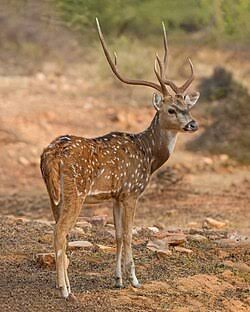

In [ ]:
from IPython.display import Image, display

display(Image("/content/images.jpg"))